# Sprint 2 : Construction d'un réseau de neurones
### Projet : Prédiction du risque de diabète - BRFSS 2015
---
**Formation** : FISE A4 Data & IA - CESI Bordeaux  
**Dataset** : `diabetes_012_health_indicators_BRFSS2015.csv`  
**Livrable** : Sprint 2 : Modèles de prédiction et leurs évaluations


## Sommaire

1. Contexte
2. Objectifs
3. Contraintes
4. Imports et configuration
5. Chargement des datasets
6. Justification des choix d'architecture
7. Construction des modèles
   - 7.1 Modèle A : Simple (1 couche cachée)
   - 7.2 Modèle B : Intermédiaire (2 couches cachées)
   - 7.3 Modèle C : Plus profond (3 couches cachées)
8. Comparaison des modèles A, B et C
9. Analyse du seuil de décision
10. Conclusion
11. Bibliographie

## 1. Contexte

&nbsp;&nbsp;&nbsp;&nbsp;Aux États-Unis, le diabète est l'une des maladies chroniques les plus répandues. En 2018, les CDC (les Centres pour le contrôle et la prévention des maladies) estimaient à 34,2 millions le nombre d'Américains diabétiques, et à 88 millions ceux en état de prédiabète, dont une grande majorité ignorait leur situation.

Cette maladie cause un dérèglement du sucre sanguin, ce qui, sur le long terme, peut engendrer des complications graves : maladies cardiovasculaires, insuffisance rénale, amputations, perte de la vue. Son coût économique est estimé à près de 300 milliards de dollars par an.

Le dataset utilisé provient du *Behavioral Risk Factor Surveillance System (BRFSS)*, une enquête téléphonique annuelle menée par les CDC auprès de plus de 400 000 Américains. Notre version (2015) contient 253 680 réponses et 22 variables relatives aux comportements de santé, antécédents médicaux et conditions socio-économiques des participants.

&nbsp;&nbsp;&nbsp;&nbsp;Le **livrable 2** constitue la partie "Construction, entraînement et évaluation de réseaux de neurones" du projet.  
C'est dans ce dernier que nous allons construire trois modèles de complexité croissante dans le but de les comparer entre eux et de choisir le plus performant pour le livrable 3. 
Cela nous permettra aussi de comprendre l'impact de la profondeur d'un réseau sur ses performances et ses limites.

L'échéance de ce livrable est fixée au 29 mai 2026 à minuit.


## 2. Objectifs

L'objectif de ce livrable est double.

D'abord, il doit nous permettre d'apprendre à construire un réseau de neurones, c'est-à-dire de comprendre comment les étapes de construction, d'entraînement et d'évaluation se définissent et s'enchaînent.

Ensuite, il doit nous permettre de comparer trois architectures de complexité différente, en faisant varier uniquement le nombre de couches cachées, tout le reste étant identique. L'idée est de voir si ajouter de la profondeur améliore vraiment les performances ou si cela crée d'autres problèmes comme le surapprentissage.

À la fin de ce livrable, on devra être capables de dire lequel des trois modèles est le "moins mauvais" ou "le plus pertinent" pour le livrable 3 et justifier ce choix.

## 3. Contraintes

Les contraintes de ce livrable sont multiples.

- Elles sont **médicales**. Si le modèle ne détecte pas un diabète chez un patient (un faux négatif), c'est bien plus grave que de signaler un diabète chez un patient qui n'en a pas. Une consultation supplémentaire "pour rien" est moins grave qu'un patient qui ne sait pas qu'il est diabétique.

- Elles sont **éthiques**. Le modèle est amené à être utilisé par des médecins. Des vies humaines sont en jeu et ce dernier a un impact direct sur l'avenir des patients.

- Le modèle doit trouver le juste milieu entre performance et explicabilité. Puisque des médecins sont amenés à l'utiliser, ils doivent pouvoir en interpréter les résultats. Si le modèle est trop complexe, il n'est pas ou peu explicable et donc pas utilisable dans la pratique.

- Le modèle doit être capable de **généraliser**, c'est-à-dire qu'il doit éviter le **surapprentissage** pour fonctionner correctement sur de nouvelles données qu'il n'a jamais vues.  
Un modèle en surapprentissage mémorise les données d'entraînement au lieu d'en apprendre les patterns généraux, il performe très bien à l'entraînement mais devient inefficace face à de nouvelles données.

- Le jeu de données présente un **déséquilibre des classes** important (86% de non-diabétiques contre 14% de diabétiques). Ce déséquilibre a été partiellement traité dans le livrable 1 via SMOTE sur le jeu d'entraînement, mais les jeux de validation et de test conservent la distribution réelle.  
L'accuracy seule ne suffit donc pas comme métrique d'évaluation.


## 4. Imports et configuration


In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# Librairies de base
import numpy as np
import pandas as pd
import time
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=tout, 1=info, 2=warning, 3=error seulement

DATA_PATH = 'data/processed/'

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

# Graine aléatoire pour la reproductibilité des résultats
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('TensorFlow version :', tf.__version__)
print('Imports OK')


TensorFlow version : 2.21.0
Imports OK


## 5. Chargement des datasets


In [2]:
# Features
X_train = pd.read_csv(os.path.join(DATA_PATH, 'X_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_PATH, 'X_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_PATH, 'X_test.csv'))

# Labels
y_train = pd.read_csv(os.path.join(DATA_PATH, 'y_train.csv'))
y_val   = pd.read_csv(os.path.join(DATA_PATH, 'y_val.csv'))
y_test  = pd.read_csv(os.path.join(DATA_PATH, 'y_test.csv'))

# Aperçu des dimensions
print('X_train :', X_train.shape)
print('X_val   :', X_val.shape)
print('X_test  :', X_test.shape)
print('y_train :', y_train.shape)
print('y_val   :', y_val.shape)
print('y_test  :', y_test.shape)


X_train : (305668, 18)
X_val   : (38052, 18)
X_test  : (38052, 18)
y_train : (305668, 1)
y_val   : (38052, 1)
y_test  : (38052, 1)


## 6. Justification des choix d'architecture

### Analyse du problème

Avant de construire les réseaux, il faut identifier les caractéristiques du problème.  
La tâche à réaliser est une **classification binaire** : on veut savoir si un patient est diabétique ou non. La sortie est donc un seul neurone avec une fonction d'activation sigmoid qui renvoie une probabilité entre 0 et 1.

### Déséquilibre des classes

L'analyse du Sprint 1 a montré une répartition d'environ 86% de non-diabétiques et 14% de diabétiques dans le dataset.  

On ne peut pas se contenter de l'accuracy pour évaluer nos modèles. Un modèle qui prédirait toujours "non diabétique" aurait 86% d'accuracy sans avoir rien appris. C'est pourquoi on utilise la **ROC-AUC** comme métrique principale : elle mesure la capacité du modèle à distinguer les deux classes, quelle que soit leur distribution. Une valeur de 1 signifie que le modèle sépare parfaitement les deux classes, une valeur de 0.5 équivaut à une prédiction aléatoire.

On surveille aussi le **recall**, car dans un contexte médical, rater un diabétique est plus grave que signaler un faux positif.

### Contrainte médicale : l'importance des faux négatifs

La matrice de confusion résume les quatre types de prédictions possibles :
- **TN** (Vrai Négatif) : non-diabétiques bien classés
- **FP** (Faux Positif) : non-diabétiques classés diabétiques : le patient fera des analyses supplémentaires, ce qui est plus acceptable
- **FN** (Faux Négatif) : diabétiques non détectés : c'est le cas le plus dangereux, le patient ne sera pas pris en charge
- **TP** (Vrai Positif) : diabétiques bien détectés : c'est ce qu'on cherche à maximiser

L'objectif est de **minimiser les FN** et donc de **maximiser le recall**.

### Équilibre entre performance et explicabilité

Plus un réseau de neurones est profond, plus il est difficile d'expliquer ses décisions. On cherche donc à construire des modèles efficaces mais pas inutilement complexes, pour que le médecin puisse comprendre et interpréter les résultats.

### Les trois architectures comparées

Dans ce livrable, on va construire et comparer **trois modèles**. Pour que la comparaison soit juste, ils partagent tous les mêmes hyperparamètres de base : même optimizer, même learning rate, même batch size, même patience, même régularisation L2 et même Dropout. La seule chose qui change est le nombre de couches cachées.

- **Modèle A (Simple)** : 1 couche cachée. C'est la base, le plus simple possible.
- **Modèle B (Intermédiaire)** : 2 couches cachées. On ajoute une couche pour voir si la performance s'améliore.
- **Modèle C (Plus profond)** : 3 couches cachées. On pousse encore un peu la profondeur.

Sur le plan éthique et légal, un modèle utilisé en milieu médical est soumis à plusieurs réglementations importantes :
- Les données de santé sont des données sensibles selon l'**article 9 du RGPD**, ce qui impose des règles strictes sur leur collecte et leur traitement.
- En France, la **CNIL** veille au respect de ces règles pour les traitements automatisés de données médicales.
- Depuis août 2024, le **règlement européen sur l'IA (AI Act, Annexe III point 5)** classe plusieurs systèmes médicaux comme systèmes à "haut risque", ce qui impose des exigences de transparence et de contrôle humain. Notre modèle s'inscrit dans cet esprit, le médecin reste seul responsable du diagnostic final, le modèle ne peut être qu'un outil d'aide à la décision.


### 6.1 Non-linéarité des données

Le graphique ci-dessous montre la distribution de cinq variables clés selon la classe cible sur les données brutes d'origine.   
On voit que les trois classes se chevauchent beaucoup, une valeur de BMI ou d'Age ne suffit pas à dire si un patient est diabétique ou non.   
Un modèle linéaire ne peut donc pas capturer ces relations, ce qui justifie l'utilisation d'un réseau de neurones avec des fonctions d'activation non-linéaires comme **ReLU** par exemple.

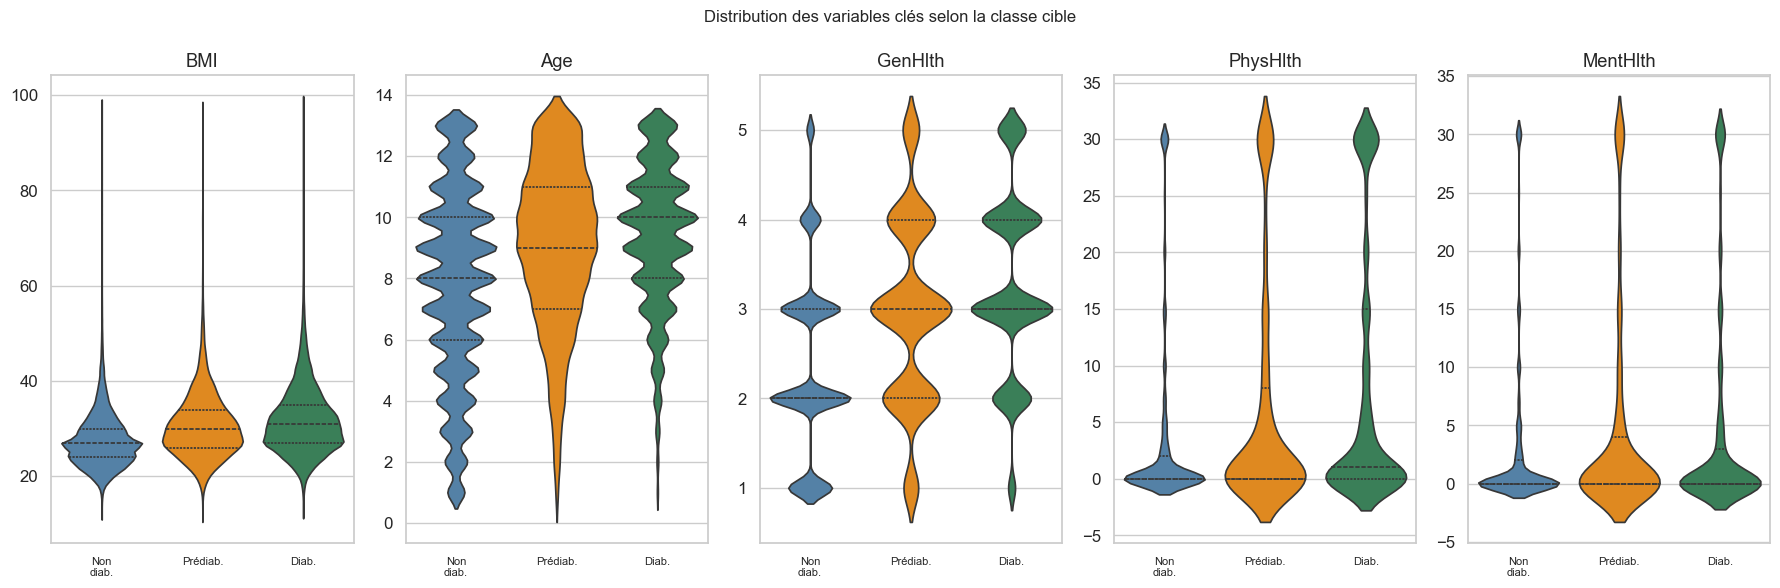

In [32]:
variables = ['BMI', 'Age', 'GenHlth', 'PhysHlth', 'MentHlth']
labels_classe = {0.0: 'Non diabétique', 1.0: 'Prédiabétique', 2.0: 'Diabétique'}
df_raw['Classe'] = df_raw['Diabetes_012'].map(labels_classe)

fig, axes = plt.subplots(1, len(variables), figsize = (18, 6))

for ax, var in zip(axes, variables):
    sns.violinplot(data = df_raw, x = 'Classe', y = var, ax = ax,
                   palette=['steelblue', 'darkorange', 'seagreen'],
                   order=['Non diabétique', 'Prédiabétique', 'Diabétique'],
                   inner='quartile')
    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_xticklabels(['Non\ndiab.', 'Prédiab.', 'Diab.'], fontsize = 8)
    ax.set_ylabel('')

plt.suptitle('Distribution des variables clés selon la classe cible', fontsize = 12)
plt.tight_layout()
plt.show()

## 7. Construction des modèles


In [3]:
input_dim = X_train.shape[1]  # nombre de features en entrée
print(f'Nombre de features en entrée : {input_dim}')


Nombre de features en entrée : 18


### Hyperparamètres communs

Pour que la comparaison entre les trois modèles soit honnête, on fixe les mêmes hyperparamètres pour tous.

- **EPOCHS = 100** : nombre maximum de passages sur les données.
- **BATCH_SIZE = 64** : les données sont traitées par paquets de 64 lignes. Après chaque paquet, le modèle ajuste ses poids.
- **LEARNING_RATE = 5e-4** : la vitesse à laquelle le modèle ajuste ses poids. Si trop grand, le modele devient instable; et lent si trop petit.
- **L2 = 1e-4** : pénalise les poids trop élevés pour éviter que le modèle ne s'adapte trop aux données d'entraînement.
- **DROPOUT = 0.3** : à chaque étape d'entraînement, 30% des neurones sont désactivés aléatoirement pour forcer le réseau à mieux généraliser.
- **PATIENCE = 10** : si la loss de validation ne s'améliore pas pendant 10 epochs consécutives, l'entraînement s'arrête et les meilleurs poids sont restaurés.
- **THRESHOLD = 0.5** : seuil de décision par défaut. Si la probabilité prédite est >= 0.5, le patient est classé diabétique.

In [4]:
# Hyperparamètres communs à tous les modèles
EPOCHS        = 100
BATCH_SIZE    = 64
LEARNING_RATE = 5e-4
L2_REG        = 1e-4
DROPOUT_RATE  = 0.3
PATIENCE      = 10
THRESHOLD     = 0.5

print('Hyperparamètres communs définis.')


Hyperparamètres communs définis.


### Rappel des mots-clés

Une couche **Dense** est une couche où chaque neurone est connecté à tous les neurones de la couche précédente. Par exemple `Dense(16, activation='relu')` signifie une couche de 16 neurones avec la fonction ReLU.

L'optimizer **Adam** est l'algorithme qui ajuste les poids du modèle après chaque erreur. On l'utilise car il adapte automatiquement la vitesse d'apprentissage pour chaque paramètre, ce qui le rend efficace sur des datasets de grande taille comme le nôtre.

La loss **binary_crossentropy** mesure l'écart entre la probabilité prédite par le modèle et la vraie classe (0 ou 1). Elle est mathématiquement adaptée aux problèmes de classification binaire.

Le **ReLU** (Rectified Linear Unit) renvoie 0 si la valeur est négative, sinon elle renvoie la valeur telle quelle. C'est la fonction d'activation standard pour les couches cachées car elle permet au réseau d'ignorer les signaux non pertinents et de laisser passer uniquement les informations utiles.

Le **Sigmoid** transforme n'importe quelle valeur en un nombre entre 0 et 1, ce qui correspond à une probabilité. C'est le bon choix pour la couche de sortie d'une classification binaire.

Le **biais** est un paramètre ajouté automatiquement par Keras à chaque couche Dense. Il permet au modèle de décaler sa sortie indépendamment des entrées. Sans lui, si toutes les entrées d'un neurone valaient 0, sa sortie serait forcément 0. Le biais lui donne plus de liberté pour s'adapter aux données.


---
### 7.1 Modèle A : Simple (1 couche cachée)

Le Modèle A est simple avec une seule couche cachée de 8 neurones.

En entrée, le réseau reçoit les variables de santé de chaque patient.  
Ces informations traversent une couche de 8 neurones où le réseau apprend à détecter les patterns dans les données.  
En sortie, un seul neurone produit une probabilité entre 0 et 1, plus elle est proche de 1, plus le patient a de risques d'être diabétique.

In [5]:
def build_model_A(input_dim):
    model = Sequential([
        Input(shape = (input_dim,)),
        Dense(8, activation = 'relu', kernel_regularizer = l2(L2_REG)), # 1 seule couche cachée : 8 neurones
        Dropout(DROPOUT_RATE),
        Dense(1, activation = 'sigmoid')                                  # sortie : probabilité entre 0 et 1
    ], name = 'model_A')

    model.compile(
        optimizer = Adam(learning_rate = LEARNING_RATE),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )
    return model

model_A = build_model_A(input_dim)
model_A.summary()

Model: "model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │             152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

#### 7.1.1 Entraînement du Modèle A

On lance l'entraînement. Le modèle va apprendre sur X_train et on surveille ses performances sur X_val à chaque epoch grâce à l'EarlyStopping.


In [6]:
early_stop_A = EarlyStopping(
    monitor = 'val_loss',
    patience = PATIENCE,
    restore_best_weights = True
)

history_A = model_A.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [early_stop_A],
    verbose = 1
)

Epoch 1/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.6936 - loss: 0.5911 - val_accuracy: 0.6916 - val_loss: 0.5381
Epoch 2/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7346 - loss: 0.5404 - val_accuracy: 0.6878 - val_loss: 0.5382
Epoch 3/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7381 - loss: 0.5372 - val_accuracy: 0.6885 - val_loss: 0.5374
Epoch 4/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7380 - loss: 0.5367 - val_accuracy: 0.6889 - val_loss: 0.5377
Epoch 5/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7385 - loss: 0.5365 - val_accuracy: 0.6907 - val_loss: 0.5378
Epoch 6/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7385 - loss: 0.5359 - val_accuracy: 0.6902 - val_loss: 0.5388
Epoch 7/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7381 - loss: 0.5355 - val_accuracy: 0.6916 - val_loss: 0.5395
Epoch 8/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7379 - loss: 0

#### 7.1.2 Évaluation sur la validation

On évalue le Modèle A sur le jeu de validation avec le seuil de 0.5 par défaut.


In [7]:
# Prédictions probabilistes
y_prob_A = model_A.predict(X_val, verbose = 0).ravel()
y_pred_A = (y_prob_A >= THRESHOLD).astype(int)

# Métriques
acc_A  = accuracy_score(y_val,  y_pred_A)
prec_A = precision_score(y_val, y_pred_A, zero_division = 0)
rec_A  = recall_score(y_val,    y_pred_A, zero_division = 0)
f1_A   = f1_score(y_val,        y_pred_A, zero_division = 0)
auc_A  = roc_auc_score(y_val,   y_prob_A)

cm_A = confusion_matrix(y_val, y_pred_A)
tn_A, fp_A, fn_A, tp_A = cm_A.ravel()

print(f'Résultats Modèle A - Validation (seuil = {THRESHOLD})')
print(f'  Accuracy  : {acc_A:.4f}')
print(f'  Precision : {prec_A:.4f}')
print(f'  Recall    : {rec_A:.4f}')
print(f'  F1-score  : {f1_A:.4f}')
print(f'  ROC-AUC   : {auc_A:.4f}')
print(f'\n  TN = {tn_A}  FP = {fp_A}')
print(f'  FN = {fn_A}  TP = {tp_A}')
print(f'\n Il y a {fn_A} diabétiques non détectés (faux négatifs)')

Résultats Modèle A - Validation (seuil = 0.5)
  Accuracy  : 0.6934
  Precision : 0.2776
  Recall    : 0.7490
  F1-score  : 0.4050
  ROC-AUC   : 0.7902

  TN = 22415  FP = 10335
  FN = 1331  TP = 3971

 Il y a 1331 diabétiques non détectés (faux négatifs)


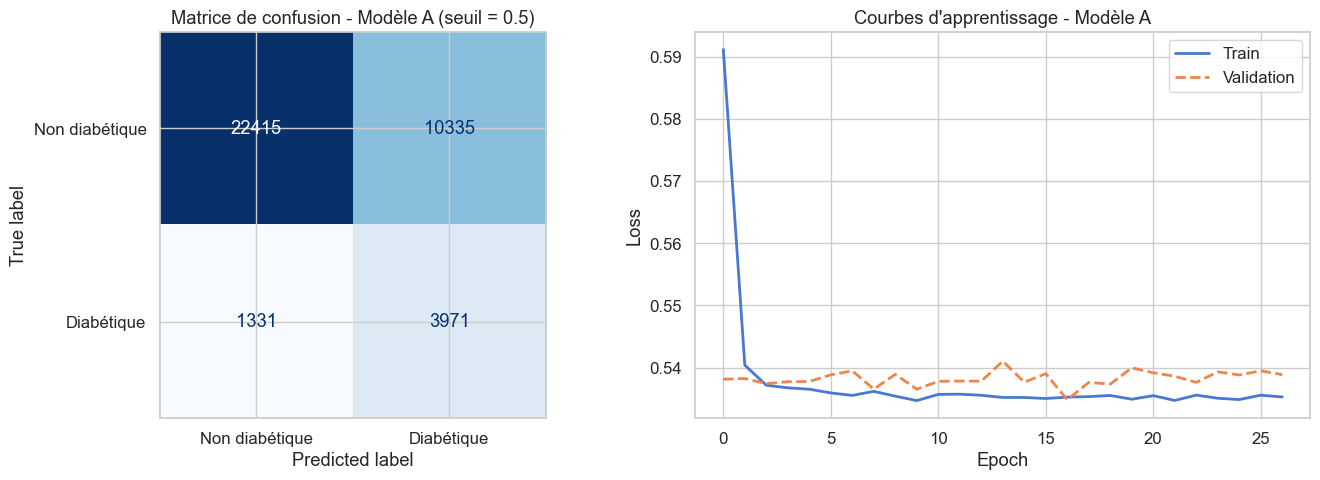

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=['Non diabétique', 'Diabétique'])
disp.plot(ax = axes[0], cmap = 'Blues', values_format = 'd', colorbar = False)
axes[0].set_title(f'Matrice de confusion - Modèle A (seuil = {THRESHOLD})')

# Courbes d'apprentissage
axes[1].plot(history_A.history['loss'], label = 'Train', linewidth = 2)
axes[1].plot(history_A.history['val_loss'], label = 'Validation', linewidth = 2, linestyle = '--')
axes[1].set_title("Courbes d'apprentissage - Modèle A")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 7.1.3 Analyse des résultats du Modèle A

Les résultats du Modèle A sont ce qu'on attendait d'une architecture très simple :

- Notre métrique principale, le **ROC-AUC, est de 0.79**. Le modèle arrive à distinguer les diabétiques des non-diabétiques dans environ 80% des cas.

- Le point le plus critique est le **FN = 1131**. Ce sont 1131 patients diabétiques que le modèle n'a pas détectés. Concrètement, ces personnes repartent sans diagnostic et sans prise en charge, exposées à des complications graves qui auraient pu être évitées. C'est ce que nos contraintes médicales cherchent à minimiser, dans ce contexte, un faux négatif est bien plus dangereux qu'un faux positif.

- Le **recall de 0.78** reflète ce chiffre, le modèle rate environ 1 diabétique sur 4. Dans un usage médical réel, ce niveau est insuffisant.

- La **precision de 0.28** génère **10 335 faux positifs**. C'est beaucoup, mais selon nos contraintes, envoyer un patient sain en consultation supplémentaire reste acceptable. Ce n'est pas notre métrique prioritaire.

- Les **courbes d'apprentissage** montrent du surapprentissage. La loss d'entraînement descend tandis que la loss de validation remonte dès l'epoch 4 et se stabilise autour de 0.540. Le modèle mémorise les données d'entraînement au lieu d'apprendre des patterns généraux, ce qui limite ses capacités de généralisation.

Sur le plan éthique et légal, le modèle n'est pas assez performant pour être utilisé en conditions réelles. L'hypothèse la plus probable est que sa capacité insuffisante ( une couche cachée de 8 neurones pour 18 variables), l'empêche de capturer la complexité des relations entre les variables du dataset.

On passe maintenant au Modèle B avec deux couches cachées, en gardant les mêmes hyperparamètres.

---
### 7.2 Modèle B : Intermédiaire (2 couches cachées)

Le Modèle B est une version légèrement plus complexe. Par rapport au Modèle A, on ajoute une deuxième couche cachée.  

Le réseau reçoit les mêmes variables en entrée, les fait passer par une première couche de 16 neurones, puis une deuxième de 8 neurones.  

In [9]:
def build_model_B(input_dim):
    model = Sequential([
        Input(shape = (input_dim,)),
        Dense(16, activation = 'relu', kernel_regularizer = l2(L2_REG)),  # 1ère couche cachée : 16 neurones
        Dropout(DROPOUT_RATE),
        Dense(8,  activation = 'relu', kernel_regularizer = l2(L2_REG)),  # 2ème couche cachée : 8 neurones
        Dropout(DROPOUT_RATE),
        Dense(1, activation = 'sigmoid')                                 # sortie
    ], name = 'model_B')

    model.compile(
        optimizer = Adam(learning_rate = LEARNING_RATE),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )
    return model

model_B = build_model_B(input_dim)
model_B.summary()

Model: "model_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 16)                  │             304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 7.2.1 Entraînement du Modèle B


In [10]:
early_stop_B = EarlyStopping(
    monitor = 'val_loss',
    patience = PATIENCE,
    restore_best_weights = True
)

history_B = model_B.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [early_stop_B],
    verbose = 1
)

Epoch 1/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7166 - loss: 0.5651 - val_accuracy: 0.6768 - val_loss: 0.5414
Epoch 2/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7357 - loss: 0.5417 - val_accuracy: 0.6861 - val_loss: 0.5365
Epoch 3/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7390 - loss: 0.5381 - val_accuracy: 0.6917 - val_loss: 0.5312
Epoch 4/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7400 - loss: 0.5351 - val_accuracy: 0.6891 - val_loss: 0.5393
Epoch 5/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7403 - loss: 0.5339 - val_accuracy: 0.6937 - val_loss: 0.5292
Epoch 6/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7403 - loss: 0.5329 - val_accuracy: 0.6946 - val_loss: 0.5337
Epoch 7/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7406 - loss: 0.5332 - val_accuracy: 0.6923 - val_loss: 0.5379
Epoch 8/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7405 - loss: 0

#### 7.2.2 Évaluation sur la validation


In [11]:
y_prob_B = model_B.predict(X_val, verbose = 0).ravel()
y_pred_B = (y_prob_B >= THRESHOLD).astype(int)

acc_B  = accuracy_score(y_val,  y_pred_B)
prec_B = precision_score(y_val, y_pred_B, zero_division = 0)
rec_B  = recall_score(y_val,    y_pred_B, zero_division = 0)
f1_B   = f1_score(y_val,        y_pred_B, zero_division = 0)
auc_B  = roc_auc_score(y_val,   y_prob_B)

cm_B = confusion_matrix(y_val, y_pred_B)
tn_B, fp_B, fn_B, tp_B = cm_B.ravel()

print(f'Résultats Modèle B - Validation (seuil = {THRESHOLD})')
print(f'  Accuracy  : {acc_B:.4f}')
print(f'  Precision : {prec_B:.4f}')
print(f'  Recall    : {rec_B:.4f}')
print(f'  F1-score  : {f1_B:.4f}')
print(f'  ROC-AUC   : {auc_B:.4f}')
print(f'\n  TN = {tn_B}  FP = {fp_B}')
print(f'  FN = {fn_B}  TP = {tp_B}')
print(f'\n Il y a {fn_B} diabétiques non détectés (faux négatifs)')

Résultats Modèle B - Validation (seuil = 0.5)
  Accuracy  : 0.6937
  Precision : 0.2804
  Recall    : 0.7654
  F1-score  : 0.4105
  ROC-AUC   : 0.7933

  TN = 22338  FP = 10412
  FN = 1244  TP = 4058

 Il y a 1244 diabétiques non détectés (faux négatifs)


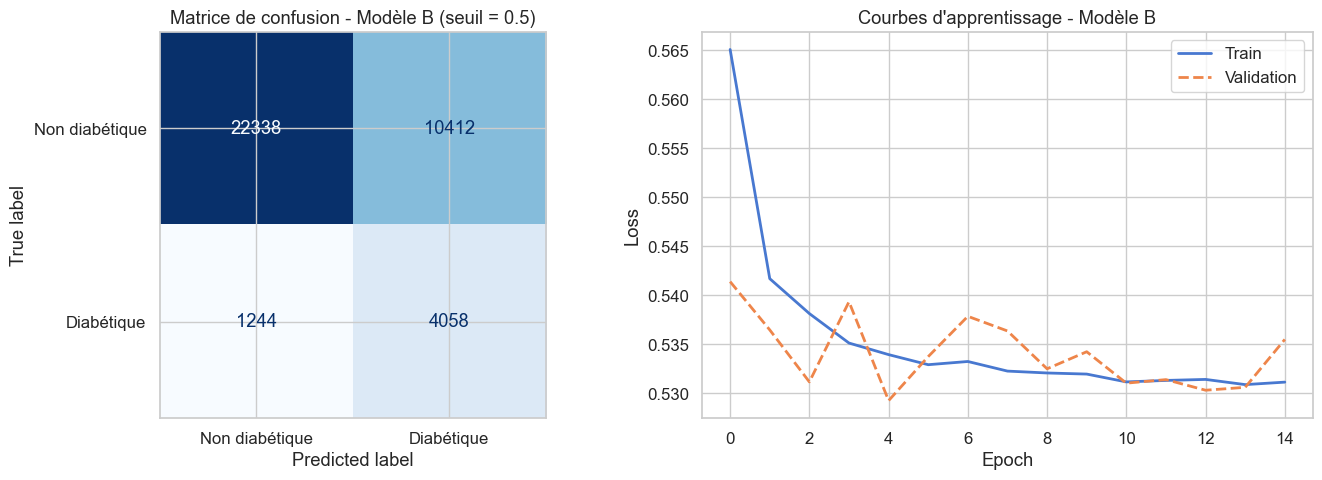

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix = cm_B, display_labels = ['Non diabétique', 'Diabétique'])
disp.plot(ax = axes[0], cmap = 'Blues', values_format = 'd', colorbar = False)
axes[0].set_title(f'Matrice de confusion - Modèle B (seuil = {THRESHOLD})')

axes[1].plot(history_B.history['loss'], label = 'Train', linewidth = 2)
axes[1].plot(history_B.history['val_loss'], label = 'Validation', linewidth = 2, linestyle = '--')
axes[1].set_title("Courbes d'apprentissage - Modèle B")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 7.2.3 Analyse des résultats du Modèle B

Observons si cette complexité supplémentaire apporte quelque chose de positif :

- Notre métrique principale, le **ROC-AUC, est de 0.794**, identique au Modèle A. Ajouter une deuxième couche cachée n'a donc pas amélioré la capacité du modèle à distinguer les diabétiques des non-diabétiques.

- Le point le plus critique est le **FN = 1244**. C'est **1244 diabétiques non détectés de plus que le Modèle A** (1131). Le Modèle B est donc moins bon que le A sur notre critère médical le plus important. Ces patients repartent sans diagnostic et sans prise en charge, ce qui est ce qu'on cherche à éviter.

- Le **recall de 0.76** confirme ce recul, le modèle rate plus d'un diabétique sur 4, contre 0.78 pour le Modèle A.

- La **precision de 0.28** génère **10 412 faux positifs**, légèrement moins que le Modèle A. Mais comme on l'a dit, ce n'est pas notre priorité, un faux positif mène à une consultation supplémentaire, ce qui reste plus acceptable.

- Les **courbes d'apprentissage** montrent un surapprentissage encore plus marqué que le Modèle A. La loss de validation oscille fortement jusqu'à l'epoch 6 environ, puis finit par remonter en fin d'entraînement, tandis que la loss d'entraînement continue de descendre. Ce comportement montre que le modèle n'a pas trouvé de minimum stable sur les données de validation.  
Ajouter une couche cachée a rendu le modèle plus instable sans le rendre plus performant.

Sur le plan éthique et légal, le modèle B n'est pas non plus assez performant pour être utilisé en conditions réelles. L'hypothèse la plus probable est que l'ajout d'une deuxième couche cachée a introduit plus de surapprentissage sans apporter de capacité de généralisation supplémentaire.

On passe maintenant au Modèle C avec trois couches cachées, toujours avec les mêmes hyperparamètres.

---
### 7.3 Modèle C : Plus profond (3 couches cachées)

Le Modèle C est le plus profond des trois. On ajoute une troisième couche cachée par rapport au Modèle B.  

Le réseau passe par trois couches successives : 32 neurones, puis 16 neurones, puis 8 neurones.  

In [13]:
def build_model_C(input_dim):
    model = Sequential([
        Input(shape = (input_dim,)),
        Dense(32, activation = 'relu', kernel_regularizer = l2(L2_REG)),  # 1ère couche cachée : 32 neurones
        Dropout(DROPOUT_RATE),
        Dense(16, activation = 'relu', kernel_regularizer = l2(L2_REG)),  # 2ème couche cachée : 16 neurones
        Dropout(DROPOUT_RATE),
        Dense(8,  activation = 'relu', kernel_regularizer = l2(L2_REG)),  # 3ème couche cachée : 8 neurones
        Dropout(DROPOUT_RATE),
        Dense(1, activation = 'sigmoid')                                 # sortie
    ], name = 'model_C')

    model.compile(
        optimizer = Adam(learning_rate = LEARNING_RATE),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )
    return model

model_C = build_model_C(input_dim)
model_C.summary()

Model: "model_C"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 32)                  │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

#### 7.3.1 Entraînement du Modèle C


In [14]:
early_stop_C = EarlyStopping(
    monitor = 'val_loss',
    patience = PATIENCE,
    restore_best_weights = True
)

history_C = model_C.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [early_stop_C],
    verbose = 1
)


Epoch 1/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7092 - loss: 0.5722 - val_accuracy: 0.6973 - val_loss: 0.5351
Epoch 2/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7402 - loss: 0.5424 - val_accuracy: 0.7074 - val_loss: 0.5267
Epoch 3/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7426 - loss: 0.5376 - val_accuracy: 0.7050 - val_loss: 0.5276
Epoch 4/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7433 - loss: 0.5352 - val_accuracy: 0.7075 - val_loss: 0.5238
Epoch 5/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7436 - loss: 0.5340 - val_accuracy: 0.7050 - val_loss: 0.5329
Epoch 6/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7441 - loss: 0.5327 - val_accuracy: 0.7109 - val_loss: 0.5278
Epoch 7/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7436 - loss: 0.5323 - val_accuracy: 0.7087 - val_loss: 0.5271
Epoch 8/100
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7441 - loss: 0

#### 7.3.2 Évaluation sur la validation


In [15]:
y_prob_C = model_C.predict(X_val, verbose = 0).ravel()
y_pred_C = (y_prob_C >= THRESHOLD).astype(int)

acc_C  = accuracy_score(y_val,  y_pred_C)
prec_C = precision_score(y_val, y_pred_C, zero_division = 0)
rec_C  = recall_score(y_val,    y_pred_C, zero_division = 0)
f1_C   = f1_score(y_val,        y_pred_C, zero_division = 0)
auc_C  = roc_auc_score(y_val,   y_prob_C)

cm_C = confusion_matrix(y_val, y_pred_C)
tn_C, fp_C, fn_C, tp_C = cm_C.ravel()

print(f'Résultats Modèle C - Validation (seuil = {THRESHOLD})')
print(f'  Accuracy  : {acc_C:.4f}')
print(f'  Precision : {prec_C:.4f}')
print(f'  Recall    : {rec_C:.4f}')
print(f'  F1-score  : {f1_C:.4f}')
print(f'  ROC-AUC   : {auc_C:.4f}')
print(f'\n  TN = {tn_C}  FP = {fp_C}')
print(f'  FN = {fn_C}  TP = {tp_C}')
print(f'\n Il y a {fn_C} diabétiques non détectés (faux négatifs)')

Résultats Modèle C - Validation (seuil = 0.5)
  Accuracy  : 0.7075
  Precision : 0.2870
  Recall    : 0.7405
  F1-score  : 0.4137
  ROC-AUC   : 0.7935

  TN = 22996  FP = 9754
  FN = 1376  TP = 3926

 Il y a 1376 diabétiques non détectés (faux négatifs)


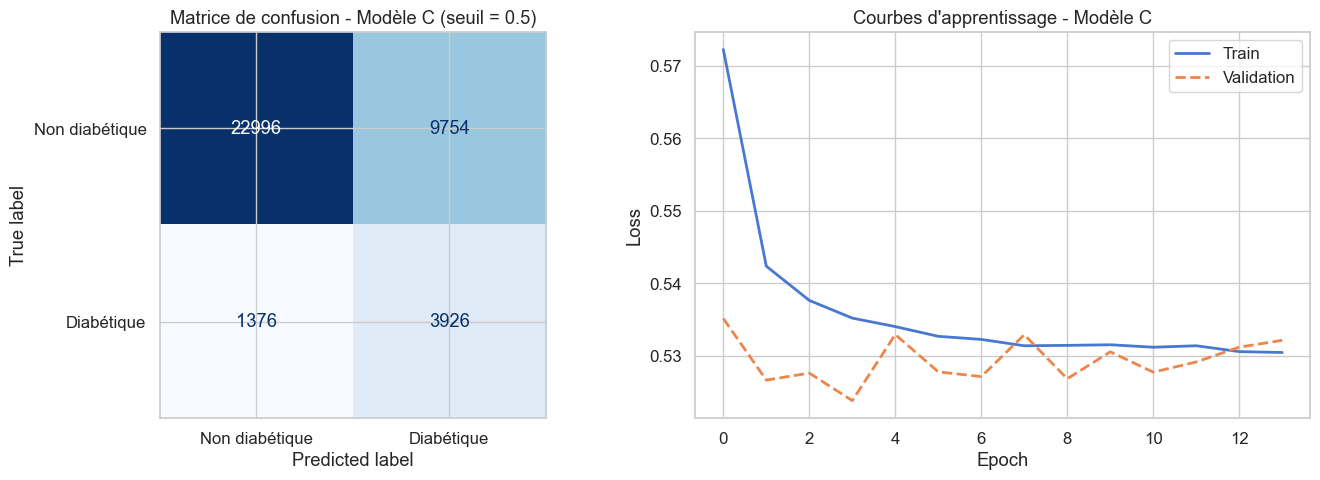

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_C, display_labels = ['Non diabétique', 'Diabétique'])
disp.plot(ax = axes[0], cmap = 'Blues', values_format = 'd', colorbar = False)
axes[0].set_title(f'Matrice de confusion - Modèle C (seuil = {THRESHOLD})')

axes[1].plot(history_C.history['loss'], label = 'Train', linewidth = 2)
axes[1].plot(history_C.history['val_loss'], label = 'Validation', linewidth = 2, linestyle = '--')
axes[1].set_title("Courbes d'apprentissage - Modèle C")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 7.3.3 Analyse des résultats du Modèle C

On observe :

- Notre métrique principale, le **ROC-AUC, est de 0.794**, légèrement au-dessus du Modèle A (0.79) et du Modèle B (0.793). La différence est minime, ajouter une troisième couche cachée n'améliore quasiment pas la capacité du modèle à distinguer les deux classes.

- Le point le plus critique est le **FN = 1376**. C'est le pire résultat des trois modèles : **245 diabétiques non détectés de plus que le Modèle A** et 132 de plus que le Modèle B. Plus on ajoute de profondeur, plus le modèle rate de diabétiques avec ces hyperparamètres. Ces patients repartent sans diagnostic et sans prise en charge, ce qui va directement à l'encontre de notre contrainte médicale principale.

- Le **recall de 0.74** confirme cette tendance, c'est le recall le plus faible des trois modèles. La profondeur supplémentaire n'aide pas à détecter plus de diabétiques.

- La **precision de 0.278** et les **9754 faux positifs** sont dans la même ligne que les modèles A et B, donc rien de notable ici.

- Les **courbes d'apprentissage** montrent le surapprentissage le plus instable des trois. La loss de validation oscille fortement dès l'epoch 2. La loss d'entraînement continue de descendre en parallèle.  
Plus le réseau est profond, plus il a tendance à mémoriser les données d'entraînement plutôt qu'à généraliser.

Sur le plan éthique et légal, le modèle C n'est pas non plus assez performant pour être utilisé en conditions réelles. L'hypothèse la plus probable est qu'avec trois couches cachées, le réseau est trop profond par rapport à la complexité réelle du problème, ce qui accentue le surapprentissage et dégrade la généralisation. Cela explique qu'il obtient le recall le plus faible des trois modèles et le plus grand nombre de diabétiques non détectés.

On va maintenant comparer les trois modèles ensemble pour choisir lequel on retient pour le livrable 3.

---
## 8. Comparaison des modèles A, B et C

Maintenant que les trois modèles ont été construits et évalués individuellement, on les compare directement.  

In [17]:
# Tableau comparatif des trois modèles
comparaison = pd.DataFrame([
    {
        'Modèle'                 : 'A - Simple',
        'Couches cachées'        : 1,
        'Architecture'           : '8',
        'Nb paramètres'          : model_A.count_params(),
        'Accuracy'               : round(acc_A,  4),
        'Precision'              : round(prec_A, 4),
        'Recall'                 : round(rec_A,  4),
        'F1-score'               : round(f1_A,   4),
        'ROC-AUC'                : round(auc_A,  4),
        'FN (diabétiques ratés)' : int(fn_A)
    },
    {
        'Modèle'                 : 'B - Intermédiaire',
        'Couches cachées'        : 2,
        'Architecture'           : '16 → 8',
        'Nb paramètres'          : model_B.count_params(),
        'Accuracy'               : round(acc_B,  4),
        'Precision'              : round(prec_B, 4),
        'Recall'                 : round(rec_B,  4),
        'F1-score'               : round(f1_B,   4),
        'ROC-AUC'                : round(auc_B,  4),
        'FN (diabétiques ratés)' : int(fn_B)
    },
    {
        'Modèle'                 : 'C - Plus profond',
        'Couches cachées'        : 3,
        'Architecture'           : '32 → 16 → 8',
        'Nb paramètres'          : model_C.count_params(),
        'Accuracy'               : round(acc_C,  4),
        'Precision'              : round(prec_C, 4),
        'Recall'                 : round(rec_C,  4),
        'F1-score'               : round(f1_C,   4),
        'ROC-AUC'                : round(auc_C,  4),
        'FN (diabétiques ratés)' : int(fn_C)
    }
])
comparaison = comparaison.set_index('Modèle')
print('Comparaison A vs B vs C (sur validation)')
comparaison

Comparaison A vs B vs C (sur validation)


,Couches cachées,Architecture,Nb paramètres,Accuracy,Precision,Recall,F1-score,ROC-AUC,FN (diabétiques ratés)
Modèle,,,,,,,,,
A - Simple,1,8,161,0.6934,0.2776,0.7490,0.4050,0.7902,1331
B - Intermédiaire,2,16 → 8,449,0.6937,0.2804,0.7654,0.4105,0.7933,1244
C - Plus profond,3,32 → 16 → 8,1281,0.7075,0.2870,0.7405,0.4137,0.7935,1376


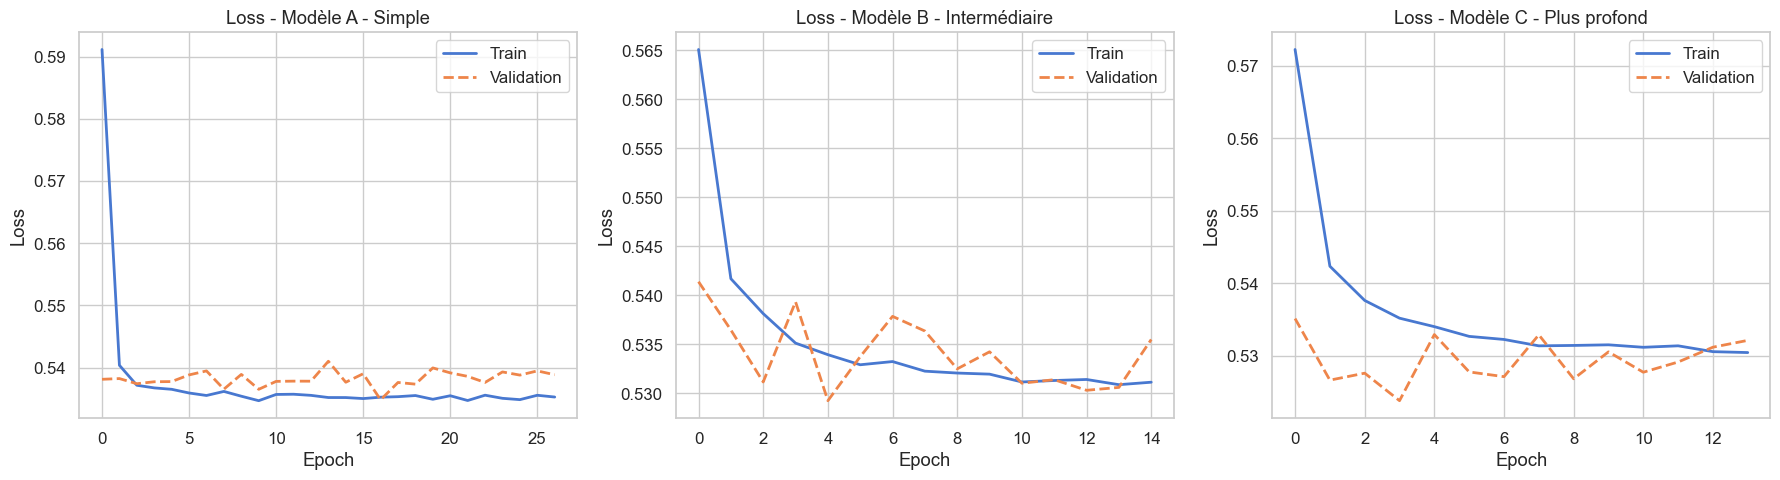

In [18]:
# Comparaison des courbes de loss des trois modèles
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, history, name in zip(
    axes,
    [history_A, history_B, history_C],
    ['Modèle A - Simple', 'Modèle B - Intermédiaire', 'Modèle C - Plus profond']
):
    ax.plot(history.history['loss'], label = 'Train', linewidth = 2)
    ax.plot(history.history['val_loss'], label = 'Validation', linewidth = 2, linestyle = '--')
    ax.set_title(f'Loss - {name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

### 8.1 Analyse de la comparaison

En regardant les résultats, les trois modèles sont très proches sur toutes les métriques. Le ROC-AUC est quasiment identique : 0.79 pour A, 0.793 pour B, 0.794 pour C.

Sur les **faux négatifs**, qui est notre critère médical prioritaire :
- Modèle A a obtenu **1131 diabétiques non détectés**
- Modèle B a obtenu **1244 diabétiques non détectés**
- Modèle C a obtenu **1376 diabétiques non détectés**

Le Modèle A fait légèrement mieux, mais l'écart est faible, c'est quelques centaines de cas sur un dataset de 250 000 lignes, avec des hyperparamètres identiques pour tout le monde qui ne sont pas forcément adaptés à chaque architecture.

Sur les **courbes d'apprentissage**, les trois font du surapprentissage. Le Modèle C est le plus instable avec une loss de validation qui oscille jusqu'à l'epoch 13, ce qui montre que trois couches cachées avec ces hyperparamètres c'est trop pour ce dataset.

**Quel modèle on retient pour le livrable 3 ?**

On retient le **Modèle B**.

Le Modèle A fait certes un peu mieux ici, mais une seule couche de 8 neurones c'est trop limité structurellement, même avec les meilleurs hyperparamètres, sa marge de progression restera faible.

Le Modèle C est écarté car il est plus lourd, plus instable, et ne fait pas mieux que le B malgré trois fois plus de paramètres.

Le Modèle B avec ses deux couches cachées (16 puis 8) est le bon compromis. Il est assez profond pour avoir de la marge de progression, assez léger pour qu'un Framework puisse tester beaucoup de combinaisons rapidement, et ses résultats actuels sont limités non pas par son architecture mais par des hyperparamètres génériques qui ne lui sont pas adaptés.  
C'est exactement le cas d'usage pour lequel la recherche automatique d'hyperparamètres est faite.

---
## 9. Analyse du seuil de décision

Jusqu'ici, on a utilisé un seuil de 0.5 pour décider si un patient est diabétique ou non. Mais ce seuil est arbitraire. On peut le modifier pour changer l'équilibre entre les faux positifs et les faux négatifs.

Dans un contexte médical, on préfère détecter trop de cas suspects plutôt que d'en rater. Baisser le seuil réduit les faux négatifs (on rate moins de diabétiques) mais augmente les faux positifs (plus de non-diabétiques envoyés en consultation). C'est un compromis à choisir en fonction du contexte.

On va analyser ce compromis pour chacun des trois modèles, puis choisir le seuil qui semble le plus adapté à notre problème.


In [20]:
def analyse_seuil(y_val, y_prob, nom_modele, seuils = None):
    """Affiche recall, precision et FN pour différents seuils de décision."""
    if seuils is None:
        seuils = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

    resultats = []
    for s in seuils:
        y_pred = (y_prob >= s).astype(int)
        rec  = recall_score(y_val,    y_pred, zero_division = 0)
        prec = precision_score(y_val, y_pred, zero_division = 0)
        f1   = f1_score(y_val,        y_pred, zero_division = 0)
        cm   = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()
        resultats.append({
            'Seuil'    : s,
            'Recall'   : round(rec,  4),
            'Precision': round(prec, 4),
            'F1-score' : round(f1,   4),
            'FN'       : fn,
            'FP'       : fp
        })
    df = pd.DataFrame(resultats).set_index('Seuil')
    print(f'\n Analyse du seuil : {nom_modele}')
    print(df.to_string())
    return df

df_seuil_A = analyse_seuil(y_val, y_prob_A, 'Modèle A')
df_seuil_B = analyse_seuil(y_val, y_prob_B, 'Modèle B')
df_seuil_C = analyse_seuil(y_val, y_prob_C, 'Modèle C')


 Analyse du seuil : Modèle A
       Recall  Precision  F1-score    FN     FP
Seuil                                          
0.30   0.9244     0.2213    0.3571   401  17243
0.35   0.8982     0.2344    0.3717   540  15557
0.40   0.8614     0.2467    0.3835   735  13948
0.45   0.8133     0.2598    0.3938   990  12284
0.50   0.7490     0.2776    0.4050  1331  10335
0.55   0.6667     0.3031    0.4168  1767   8126
0.60   0.5732     0.3288    0.4178  2263   6205

 Analyse du seuil : Modèle B
       Recall  Precision  F1-score    FN     FP
Seuil                                          
0.30   0.9206     0.2224    0.3582   421  17068
0.35   0.8914     0.2368    0.3742   576  15232
0.40   0.8559     0.2501    0.3871   764  13605
0.45   0.8174     0.2640    0.3991   968  12085
0.50   0.7654     0.2804    0.4105  1244  10412
0.55   0.7035     0.2972    0.4179  1572   8820
0.60   0.6209     0.3186    0.4211  2010   7042

 Analyse du seuil : Modèle C
       Recall  Precision  F1-score    FN     F

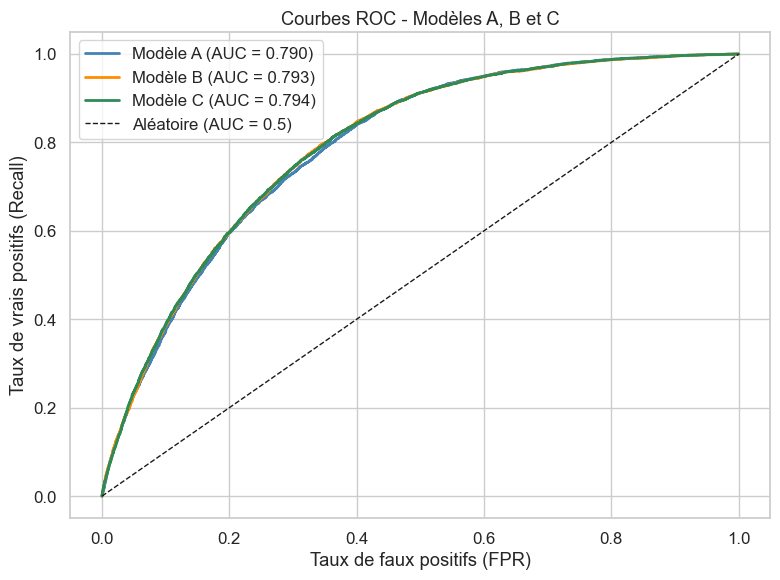

In [21]:
# Courbes ROC des trois modèles
fig, ax = plt.subplots(figsize = (8, 6))

for y_prob, auc_val, label, color in [
    (y_prob_A, auc_A, 'Modèle A (AUC = {:.3f})'.format(auc_A), 'steelblue'),
    (y_prob_B, auc_B, 'Modèle B (AUC = {:.3f})'.format(auc_B), 'darkorange'),
    (y_prob_C, auc_C, 'Modèle C (AUC = {:.3f})'.format(auc_C), 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    ax.plot(fpr, tpr, label = label, linewidth = 2, color = color)

ax.plot([0, 1], [0, 1], 'k--', linewidth = 1, label = 'Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (Recall)')
ax.set_title('Courbes ROC - Modèles A, B et C')
ax.legend()
plt.tight_layout()
plt.show()

### 9.1 Analyse du seuil

Les trois courbes ROC sont quasiment superposées avec un AUC de 0.794 pour les trois modèles. Ça confirme ce qu'on avait déjà observé, les trois architectures ont exactement la même capacité de discrimination, quel que soit le seuil choisi.

En regardant les tableaux, on voit clairement l'arbitrage entre recall et faux négatifs selon le seuil :

À **seuil = 0.30**, le Modèle A ne rate plus que **401 diabétiques** pour un recall de 0.924, mais génère 17 243 faux positifs. Le Modèle B en rate 421 et le C 420.

À **seuil = 0.35**, le Modèle A rate **540 diabétiques**, le B **576**, le C **607**. Les faux positifs descendent autour de 15 000 - 16 000.

À **seuil = 0.40**, le Modèle A rate **735 diabétiques**, le B **764**, le C **869**. C'est un meilleur équilibre entre recall et faux positifs.

À **seuil = 0.50** (défaut), on retombe sur les résultats déjà analysés : 1331, 1244 et 1376 faux négatifs respectivement.

Dans notre contexte médical, baisser le seuil est justifié. Chaque faux négatif évité c'est un patient diabétique qui reçoit un diagnostic et une prise en charge. Les faux positifs supplémentaires se traduisent par des consultations inutiles, ce qui est plus acceptable.

Un seuil autour de **0.35 à 0.40** semble être le bon compromis. On réduit significativement les faux négatifs par rapport au seuil par défaut, sans non plus classer la moitié de la population comme diabétique.  
C'est ce seuil qu'on retiendra pour la comparaison finale et qu'on optimisera dans le livrable 3.

## 10. Conclusion

Dans ce livrable, on a construit et comparé trois réseaux de neurones qui ne diffèrent que par leur nombre de couches cachées. Tout le reste est identique pour que la comparaison soit honnête.

Le premier enseignement c'est que ajouter des couches ne suffit pas. Les trois modèles donnent des résultats très proches avec un ROC-AUC de 0.794 pour tous. Le Modèle A fait même légèrement mieux sur les faux négatifs (1331 contre 1244 et 1376), ce qui montre que le problème de performance ne vient pas de l'architecture mais des hyperparamètres qui ne sont pas adaptés à chaque modèle.

Le deuxième enseignement c'est que le surapprentissage est présent sur les trois modèles. La loss d'entraînement descend mais la loss de validation se stabilise ou oscille. Le Modèle C est le plus instable sur ce point.

Cependant, étant donné que l'écart de performance entre le Modèle B et le Modèle C reste faible, le Modèle C ne sera pas totalement écarté. Une fois le Modèle B optimisé dans le livrable 3, le Modèle C fera également l'objet d'une recherche automatique d'hyperparamètres qui lui sont propres, afin de vérifier s'il s'avère finalement meilleur.

Sur l'**analyse de seuil**, on a vu qu'un seuil de 0.5 n'est pas adapté à notre contexte médical. Baisser le seuil réduit significativement les faux négatifs, c'est-à-dire les diabétiques non détectés. Ce point sera traité dans le livrable 3.

**Le modèle retenu pour le livrable 3 est le Modèle B.** Le Modèle A est trop simple structurellement pour progresser significativement. Le Modèle C est plus lourd et plus instable sans être meilleur que le B.  
Le Modèle B est le bon compromis. Il est assez profond pour avoir de la marge de progression, assez léger pour que la recherche automatique d'hyperparamètres soit efficace.

**Dans le livrable 3**, on utilisera un framework de recherche automatique d'hyperparamètres pour trouver la meilleure combinaison possible pour le Modèle B, et on optimisera le seuil de décision en fonction de nos contraintes médicales.

## 11. Bibliographie

- Union européenne. (2024). Règlement (UE) 2024/1689 du Parlement européen et du Conseil du 13 juin 2024 établissant des règles harmonisées concernant l'intelligence artificielle (règlement sur l'IA). *Journal officiel de l'Union européenne*. https://eur-lex.europa.eu/legal-content/FR/TXT/?uri=CELEX:32024R1689

- Union européenne. (2016). Règlement (UE) 2016/679 du Parlement européen et du Conseil du 27 avril 2016 relatif à la protection des personnes physiques à l'égard du traitement des données à caractère personnel (RGPD), article 9. https://www.cnil.fr/fr/reglement-europeen-protection-donnees/chapitre2#Article9

- Future of Life Institute. (s.d.). AI Act - Annexe III : Systèmes d'IA à haut risque. *Artificial Intelligence Act*. https://artificialintelligenceact.eu/fr/annex/3
